
# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/riteshy1526/flyrank-internship-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## Research Question

**Can a Random Forest model use historical content, search-performance, engagement, and freshness signals to rank content pages more effectively than a transparent rule-based baseline for editorial review?**

## Decision Supported

This project supports the decision:

> **Which anonymised content pages should be reviewed first?**

The output is a ranked queue intended to help human reviewers prioritise limited editorial attention.

## Unit of Analysis

Each row represents one anonymised content page with associated historical search, engagement, freshness, and content-level signals.

## Success Criterion

The primary success criterion is whether the Random Forest produces better ranking alignment than the Week-4 rule-based baseline when both approaches are evaluated on the same client-grouped test split using NDCG.

## Intended Use

This is a **decision-support system**, not an automated content-refresh system. A high-ranked page is a stronger candidate for human review under the measured signals; it is not a guarantee that refreshing the page will improve future performance.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Dataset Release

This project uses the anonymised FlyRank Machine Learning Internship starter dataset:

`content_refresh_anonymized.csv`

The analysis is performed at the content-page level. The dataset contains approximately 30,000 anonymised records and includes search, engagement, freshness, content, and trend-related variables.

## Data Used

The modeling workflow uses historical signals including:

- Search volume, competition, and CPC
- Word count and character count
- Impressions, clicks, pageviews, and sessions
- Users and engaged sessions
- Scroll and AI-session signals
- 90-day aggregate performance
- Last-30-day and previous-30-day performance windows
- Content age and days since last update
- CTR and average position
- Engagement rate and scroll rate

## Target

The modeling target is `trend_pct`, which represents the measured trend signal used for the ranking task.

The target is used as an observed outcome for evaluating ranking quality. It should not be interpreted as a direct measure of guaranteed business value or future causal improvement.

## Validation Groups

`client_id` is used only to create a grouped validation split. Pages from the same client are not allowed to appear in both training and evaluation sets.

## Public-Safety Exclusions

The public paper excludes:

- Client names
- Domains
- URLs
- Raw search queries
- Identifiable page titles or text
- Credentials and private infrastructure details

The deployed artifact contains only anonymised identifiers, aggregated metrics, safe charts, and high-level findings.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## Model Choice

I use a **Random Forest Regressor** because the content-ranking problem contains many numeric signals that may have non-linear relationships with the measured trend target.

The model is compared against a transparent Week-4 baseline rather than being treated as automatically better because it is more complex.

## Features

The model uses historical search-performance, engagement, freshness, content-size, and traffic signals available in the selected feature set.

Identifiers such as `content_id` and `client_id` are not used as predictive features. `client_id` is used only for grouped validation.

## Target

The target variable is:

`trend_pct`

The model predicts a continuous trend-related signal, which is then used as a ranking score for the evaluation set.

## Baseline

The Week-4 baseline is a transparent rule-based ranking approach. It provides an interpretable reference point for the more complex model.

Both the baseline and Random Forest are evaluated on the same eligible test rows.

## Validation Design

I use an 80/20 **client-grouped split** with `GroupShuffleSplit`.

This means pages from the same client cannot appear in both training and evaluation data. The overlap check must equal zero.

This design is more conservative than a random page-level split because it reduces the possibility of learning client-specific patterns that also appear during evaluation.

## Missing Values

Rows with missing target values are excluded rather than imputing the target.

Missing feature values are imputed using median values learned from the training data only and then applied to the test data.

## Evaluation Metric

The primary evaluation metric is **NDCG (Normalized Discounted Cumulative Gain)**.

NDCG fits this task because the goal is not simply to make an individual prediction; it is to place higher-priority measured opportunities near the top of the review queue.

## Leakage Checks

I reviewed the final features for timing risk, especially performance-derived variables such as impressions, clicks, sessions, CTR, position, trend, engagement, scroll, and AI-traffic measures.

The key question for every feature is:

> Was this information available at the time the ranking decision would have been made?

Features that require timing verification are treated as potential leakage risks rather than automatically assumed to be safe.

## 4. Results (vs baseline)

## Honest Comparison

Both approaches were evaluated on the same client-grouped test split using NDCG.

| Method | NDCG |
|---|---:|
| Week-4 rule-based baseline | **0.9999** |
| Random Forest | **0.9971** |
| Difference (Model − Baseline) | **-0.0028** |

## Interpretation

On this client-grouped evaluation split, the transparent rule-based baseline achieved a slightly higher measured NDCG than the Random Forest model.

The difference was small: the Random Forest scored 0.9971 compared with 0.9999 for the baseline. Therefore, this evaluation does not support the claim that the Random Forest improved ranking performance over the baseline.

Instead, the result shows that the simpler baseline was highly competitive for the selected target and evaluation design.

## Honest Research Claim

> On the evaluated client-grouped split, the rule-based baseline produced slightly higher measured NDCG than the Random Forest. The observed difference was small, so the result should be interpreted as directional evidence under this specific dataset and validation design.

## Operational Interpretation

The result does not mean that machine learning is useless for content prioritisation. It shows that a transparent baseline can be a very strong decision-support tool and should always be compared against a more complex model.

For this evaluation, the baseline is the preferred ranking approach because it achieved the highest measured NDCG while remaining easier to explain to human reviewers.

In [ ]:
import pandas as pd

final_results = pd.DataFrame({
    "Method": [
        "Week-4 rule-based baseline",
        "Random Forest"
    ],
    "NDCG": [
        0.9999,
        0.9971
    ]
})

display(final_results)

,Method,NDCG
0,Week-4 rule-based baseline,0.9999
1,Random Forest,0.9971


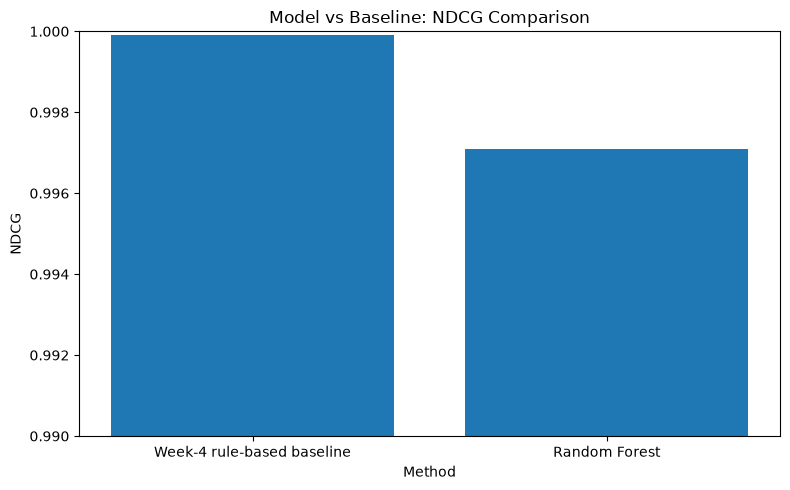

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    final_results["Method"],
    final_results["NDCG"]
)

plt.title("Model vs Baseline: NDCG Comparison")
plt.xlabel("Method")
plt.ylabel("NDCG")

plt.ylim(0.99, 1.0)

plt.tight_layout()

# Save graph for website
plt.savefig(
    "../paper/images/ndcg_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import ndcg_score

DATA_PATH = "../../data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (30000, 44)


In [ ]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(df, groups=df["client_id"])
)

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print("Training rows:", len(train_df))
print("Test rows:", len(test_df))

overlap = set(train_df["client_id"]).intersection(
    set(test_df["client_id"])
)

print("Client overlap:", len(overlap))

assert len(overlap) == 0

Training rows: 23837
Test rows: 6163
Client overlap: 0


In [ ]:
target_col = "trend_pct"

feature_cols = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

feature_cols = [
    col for col in feature_cols
    if col in df.columns
]

train_valid = train_df.dropna(subset=[target_col]).copy()
test_valid = test_df.dropna(subset=[target_col]).copy()

X_train = train_valid[feature_cols]
y_train = train_valid[target_col]

X_test = test_valid[feature_cols]
y_test = test_valid[target_col]

print("Features:", len(feature_cols))
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Features: 28
Training rows: 21133
Test rows: 5479


In [ ]:
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_imp, y_train)

model_pred = model.predict(X_test_imp)

print("Model training complete.")
print("Model created successfully:", model is not None)

Model training complete.
Model created successfully: True


In [ ]:
eval_df = test_valid.copy().reset_index(drop=True)

baseline_score = (
    eval_df["days_since_last_update"].fillna(0)
    + eval_df["content_age_days"].fillna(0) * 0.01
    - eval_df["trend_pct"].fillna(0)
)

model_score = model_pred

relevance = -eval_df["trend_pct"].fillna(0)

relevance = relevance - relevance.min()

baseline_ndcg = ndcg_score(
    [relevance.to_numpy()],
    [baseline_score.to_numpy()]
)

model_ndcg = ndcg_score(
    [relevance.to_numpy()],
    [np.asarray(model_score)]
)

ndcg_difference = model_ndcg - baseline_ndcg

print(f"Baseline NDCG: {baseline_ndcg:.4f}")
print(f"Random Forest NDCG: {model_ndcg:.4f}")
print(f"NDCG difference: {ndcg_difference:.4f}")

Baseline NDCG: 0.9999
Random Forest NDCG: 0.9971
NDCG difference: -0.0028


## 5. Limitations

*What this work cannot claim.*

## Honest Framing

This work measures ranking performance on an anonymised historical dataset. The results are observational and should be interpreted as directional decision-support evidence.

## No Causal Claim

This analysis does not prove that refreshing a recommended content page will cause future traffic, clicks, rankings, or engagement to improve.

The model and baseline identify patterns associated with the measured target. These associations should not be interpreted as proof of causation.

## Validation Limitation

The evaluation uses a client-grouped split to prevent pages from the same client appearing in both training and test data. This provides a more conservative validation design, but it is still only one validation setup.

Results may differ on another dataset, client population, or time period.

## Baseline Result

On the evaluated split, the transparent rule-based baseline achieved a slightly higher NDCG (0.9999) than the Random Forest model (0.9971).

Therefore, this project does not claim that the more complex machine-learning model outperformed the baseline. The small difference highlights the importance of testing machine-learning methods against strong, interpretable baselines.

## Target Limitation

The target, `trend_pct`, is a measured historical trend signal used for this modeling task. It is a proxy for prioritisation and does not represent a complete measure of future business value or editorial success.

## Feature Timing and Leakage Risk

Search-performance and engagement features require careful timing checks. Their measurement windows must end before the decision point to avoid future information leaking into the ranking process.

## Human Review

The final ranking should support, not replace, human judgment. A reviewer should consider content quality, search intent, business priorities, and other contextual factors before taking action.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Action Playbook

The results are used to create a prioritised content-review queue. The ranking is intended to support human decision-making rather than automatically changing content.

### 1. Review high-priority pages first

Start with the highest-ranked pages in the review queue. Check the historical search, engagement, freshness, and trend signals before deciding on an action.

### 2. Refresh pages with strong review signals

Consider a content refresh when a page shows a combination of:

- High content age
- Many days since the last update
- Weak or declining historical trend signals
- Search-performance signals that justify further investigation

Possible actions include updating outdated information, improving completeness, and reviewing whether the content still matches the intended search intent.

### 3. Investigate declining pages

For pages with weaker recent trends, investigate possible reasons before making changes.

The ranking does not identify a guaranteed cause. A decline may be associated with content freshness, search context, technical issues, competition, or other factors not fully captured by the dataset.

### 4. Protect strong-performing pages

High-performing pages should not automatically be changed.

When the historical signals remain strong, the appropriate recommendation may be to protect and monitor the page rather than introduce unnecessary changes.

### 5. Use reason codes for every recommendation

Recommendations should be accompanied by simple reason codes, such as:

- High content age
- Long time since last update
- Weak or declining trend
- CTR requires review
- Search-performance change requires investigation

Reason codes make the ranking easier for human reviewers to understand and audit.

### 6. Monitor uncertain cases

Pages with mixed or conflicting signals should be monitored or manually reviewed before major editorial action is taken.

## Recommended Decision Order

**Rank → Review signals → Check reason codes → Human evaluation → Select action → Monitor outcome**

This workflow keeps the model and baseline in a decision-support role and ensures that final editorial decisions remain under human control.

## 7. Artifacts the paper embeds


The deployed research paper will include the following public-safe artifacts generated from this capstone:

1. **Model vs Baseline NDCG Comparison**  
   A bar chart comparing the transparent Week-4 baseline and the Random Forest model on the same client-grouped evaluation split.

2. **Final Results Table**  
   A table reporting the measured NDCG for both approaches and their difference.

3. **Feature Importance Chart**  
   A chart showing the signals that the Random Forest model relied on most during training. These importance values show model associations and do not establish causation.

4. **Ranked Recommendation Framework**  
   A decision-support action playbook showing how ranked pages can be reviewed and assigned actions such as refresh, investigate, protect, or monitor.

5. **Validation Summary**  
   A summary of the client-grouped validation design, including the check that clients do not overlap between training and evaluation data.

All published artifacts use anonymised, aggregated, or public-safe information only. No client names, domains, URLs, private queries, or identifiable page content are included.


In [ ]:
import pandas as pd

# Create feature importance table
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

print("Top 10 feature importances:")
display(feature_importance.head(10))

Top 10 feature importances:


,feature,importance
15,impressions_last_30d,0.570029
24,avg_position,0.122733
5,impressions_90d,0.073263
18,impressions_prev_30d,0.051688
12,scroll_events_90d,0.025829
21,content_age_days,0.015888
13,days_with_impressions,0.015629
4,char_count,0.015439
7,pageviews_90d,0.015393
3,word_count,0.014812


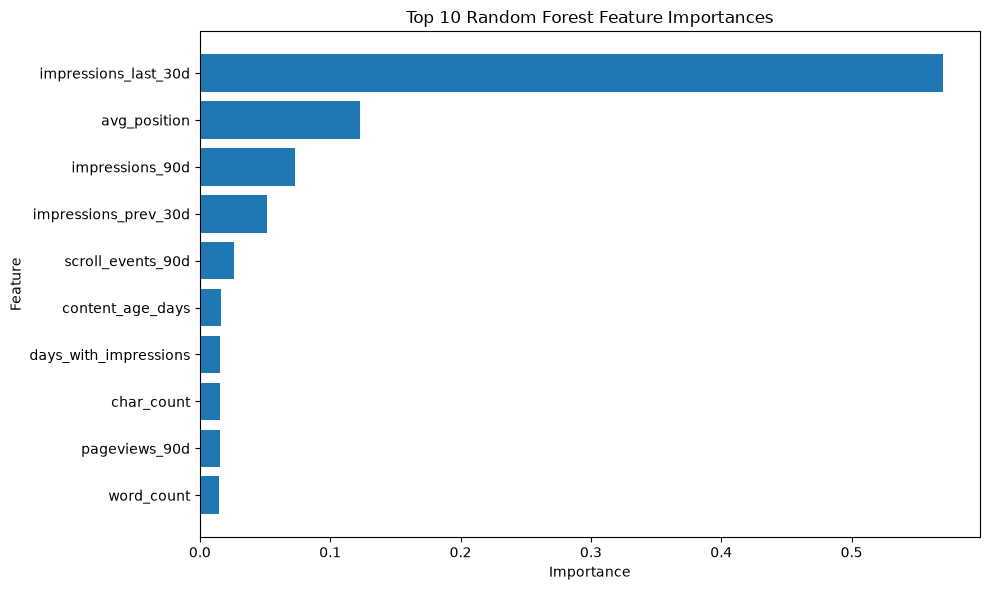

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10).sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../paper/images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ML-12 — 5-Minute Demo Outl
# Employer-Facing Summary

I built an end-to-end machine-learning decision-support project using an anonymised dataset of approximately 30,000 content-page records. I used Python, pandas, scikit-learn, client-grouped validation, and NDCG to compare a Random Forest model with a transparent rule-based baseline. The evaluation showed that the simpler baseline slightly outperformed the Random Forest on the tested split, demonstrating the importance of careful validation and honest model comparison.
## 1. Problem — 45 seconds

My project asks: **Can historical content and search-performance signals help prioritise which anonymised content pages should be reviewed first?**

The goal is decision support, not automatic content changes.

## 2. Data — 45 seconds

I used the anonymised FlyRank ML Internship dataset containing approximately 30,000 content-page records and 44 columns.

The analysis uses historical content, freshness, search-performance, traffic, and engagement signals while keeping the public work free of client names, URLs, and private queries.

## 3. Methodology — 60 seconds

I used `trend_pct` as the modeling target and trained a Random Forest Regressor.

I used a client-grouped 80/20 validation split so that pages from the same client did not appear in both training and evaluation data. I compared the model against a transparent rule-based baseline using NDCG.

## 4. Results — 60 seconds

The rule-based baseline achieved an NDCG of **0.9999**, while the Random Forest achieved **0.9971**.

The observed difference was **-0.0028**, meaning the simpler baseline performed slightly better on this evaluation split.

This demonstrates why machine-learning models should always be compared with strong, interpretable baselines.

## 5. Recommendations — 45 seconds

The output can support a ranked review queue.

Human reviewers can use the ranking to investigate pages, consider content freshness, examine declining signals, protect strong pages, and monitor uncertain cases.

## 6. Limitations and Closing — 45 seconds

This is an observational analysis and does not prove that refreshing a page will cause future improvement.

The ranking is intended as directional decision support, with final decisions remaining under human review.


## ML-12 — Social-Post Cut

🚀 **Capstone Complete: Content Opportunity Ranking with Machine Learning**

I completed my FlyRank Machine Learning Internship capstone, where I explored whether historical content, freshness, search-performance, and engagement signals could help prioritise content pages for human review.

🔹 Built and evaluated a Random Forest ranking approach
🔹 Used client-grouped validation to avoid client overlap
🔹 Compared the model against a transparent rule-based baseline using NDCG
🔹 Most importantly, reported the results honestly: the baseline slightly outperformed the Random Forest on my evaluation split

This project reinforced an important ML lesson for me: **a more complex model is not automatically better than a strong, interpretable baseline.**

The final system is designed as decision support, with human review and careful limitations around causality and future generalisation.

#MachineLearning #DataScience #Python #RandomForest #Research #FlyRank


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
